In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/777uyyu/y_test.csv
/kaggle/input/777uyyu/X_test.csv
/kaggle/input/777uyyu/y_train.csv
/kaggle/input/777uyyu/X_train.csv


In [2]:
!pip uninstall -y scikit-learn
!pip install scikit-learn==1.4.2

Found existing installation: scikit-learn 1.2.2
Uninstalling scikit-learn-1.2.2:
  Successfully uninstalled scikit-learn-1.2.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 102.3 MB/s eta 0:00:00


In [3]:
!pip install scikeras

In [4]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

In [5]:
X_train = pd.read_csv('//kaggle/input/777uyyu/X_train.csv')
y_train = pd.read_csv('/kaggle/input/777uyyu/y_train.csv')
X_test = pd.read_csv('/kaggle/input/777uyyu/X_test.csv')
y_test = pd.read_csv('/kaggle/input/777uyyu/y_test.csv')

X_train = X_train.drop(columns = ['UserName'], axis=1)
X_test = X_test.drop(columns = ['UserName'], axis=1)

Training Logistic Regression...


/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best params for Logistic Regression: {'C': 1, 'solver': 'liblinear'}
Metrics: Acc=0.7404, Prec=0.7493, Rec=0.8509, F1=0.7969, AUC=0.7769

Training KNN...


/usr/local/lib/python3.10/dist-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Best params for KNN: {'n_neighbors': 9, 'weights': 'uniform'}
Metrics: Acc=0.7529, Prec=0.7638, Rec=0.8498, F1=0.8045, AUC=0.7955

Training Random Forest...


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Best params for Random Forest: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Metrics: Acc=0.7887, Prec=0.7637, Rec=0.9369, F1=0.8415, AUC=0.8490

Training MLP...


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1101: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best params for MLP: {'activation': 'logistic', 'alpha': 0.01, 'early_stopping': True, 'hidden_layer_sizes': (50, 50), 'learning_rate': 'adaptive', 'n_iter_no_change': 10}
Metrics: Acc=0.7856, Prec=0.7861, Rec=0.8816, F1=0.8311, AUC=0.8451



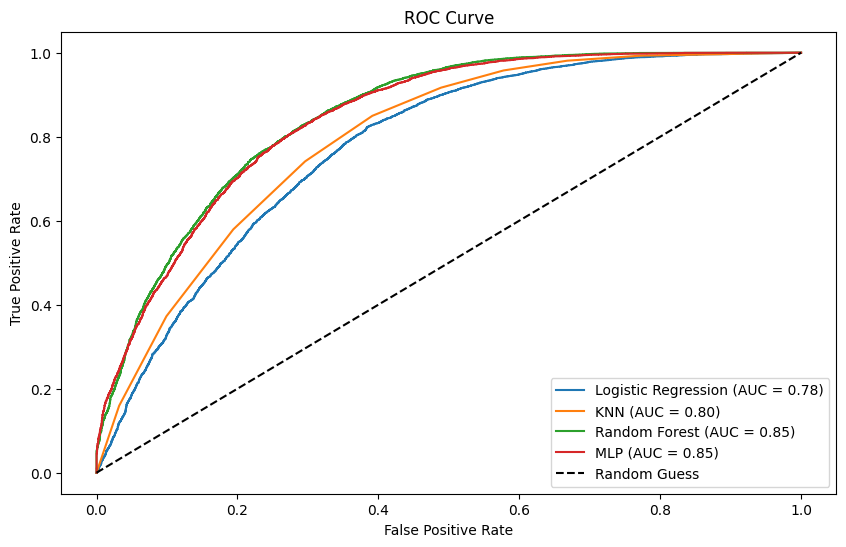

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.neural_network import MLPClassifier


# Define models and hyperparameters
models = {
    "Logistic Regression": (LogisticRegression(), {
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear', 'lbfgs']
    }),
    "KNN": (KNeighborsClassifier(), {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance']
    }),
    "Random Forest": (RandomForestClassifier(), {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10]
    }),
    "MLP": (MLPClassifier(), {
    'hidden_layer_sizes': [(100,), (50, 50), (100, 50)],
    'activation': ['logistic'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['adaptive'],
    'early_stopping': [True], #Enable early stopping
    'n_iter_no_change': [10] #Number of epochs with no improvement after which training will be stopped
})
}

best_models = {}
results = {}

# Train models and find best parameters
for name, (model, params) in models.items():
    print(f"Training {name}...")
    grid_search = GridSearchCV(model, params, cv=5, scoring='accuracy', n_jobs=-1)

    
    grid_search.fit(X_train, y_train)
    
    best_model = grid_search.best_estimator_
    best_models[name] = best_model

    # Predictions
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, "predict_proba") else None

    # # Compute Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None

    
    results[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1 Score": f1, "AUC": auc}
    print(f"Best params for {name}: {grid_search.best_params_}")
    print(f"Metrics: Acc={acc:.4f}, Prec={prec:.4f}, Rec={rec:.4f}, F1={f1:.4f}, AUC={auc:.4f}\n")

# Plot ROC Curve
plt.figure(figsize=(10, 6))

for name, model in best_models.items():
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc_score = roc_auc_score(y_test, y_proba)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
